In [1]:
import pandas as pd
import matplotlib as plt

In [2]:
rs50_data = pd.read_csv("Reliance_RS50.csv", skiprows=1)

In [3]:
rs50_data

,Time [s],Voltage [V],SOC [%],Power [W],Current [A],Charge [Ah],Temperature [°C],Heat Generation [W],Cooling Power [W]
0,0.0,4.149204,100.000000,-20.746020,-5,0.000000,25.000000,-0.073669,0.000000
1,0.1,4.148540,99.997222,-20.742701,-5,-0.000139,24.999881,-0.070776,0.000032
2,0.2,4.147889,99.994444,-20.739446,-5,-0.000278,24.999766,-0.067946,0.000063
3,0.3,4.147250,99.991667,-20.736251,-5,-0.000417,24.999657,-0.065177,0.000093
4,0.4,4.146623,99.988889,-20.733117,-5,-0.000556,24.999551,-0.062469,0.000122
...,...,...,...,...,...,...,...,...,...
36928,3692.8,2.500651,-2.577778,-12.503256,-5,-5.128889,31.004861,1.840559,-1.630691
36929,3692.9,2.500476,-2.580556,-12.502379,-5,-5.129028,31.005208,1.840807,-1.630785
36930,3693.0,2.500300,-2.583333,-12.501502,-5,-5.129167,31.005555,1.841054,-1.630879
36931,3693.1,2.500125,-2.586111,-12.500624,-5,-5.129306,31.005902,1.841301,-1.630974


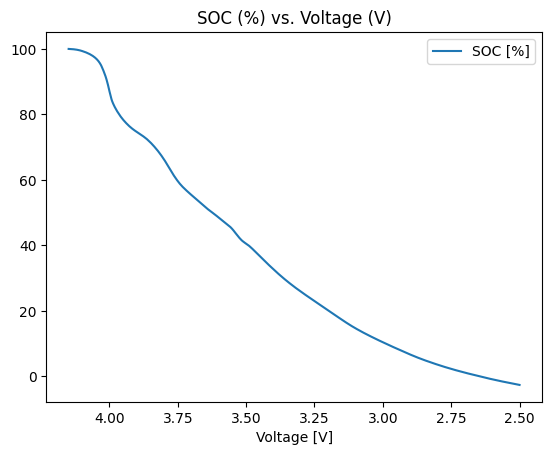

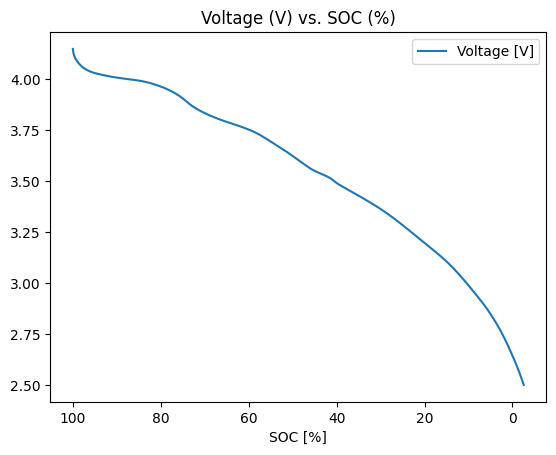

In [26]:
ax = rs50_data.plot(x="Voltage [V]", y = "SOC [%]")
ax.set_title("SOC (%) vs. Voltage (V)")
ax.invert_xaxis()

ax = rs50_data.plot(x="SOC [%]", y = "Voltage [V]")
ax.set_title("Voltage (V) vs. SOC (%)")
ax.invert_xaxis()

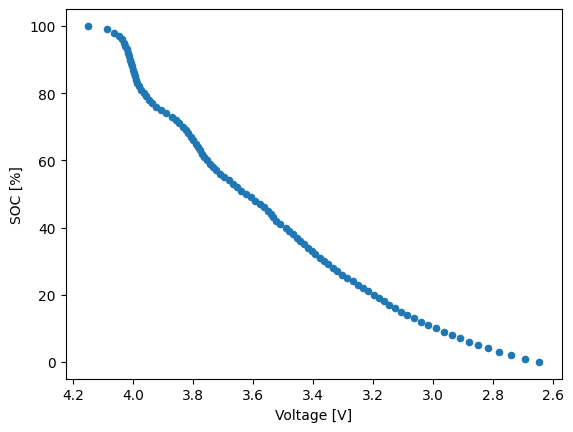

In [4]:
estimate_100_pts = (
    rs50_data[["Voltage [V]", "SOC [%]"]]
    .dropna()
    .assign(
        SOC_target_pct=lambda d: d["SOC [%]"].round().astype(int),
        error=lambda d: (d["SOC [%]"] - d["SOC [%]"].round()).abs()
    )
    .query("SOC_target_pct >= 0 and SOC_target_pct <= 100")
    .sort_values("error")                         # best match first
    .drop_duplicates("SOC_target_pct", keep="first")  # one row per percent
    .sort_values("SOC_target_pct", ascending=False)
    .drop(columns="error")
    .reset_index(drop=True)
)


ax = estimate_100_pts.plot(x="Voltage [V]", y="SOC [%]", kind="scatter")
ax.invert_xaxis()



In [6]:
from generate_ocv_table import write_ocv_header

FILE_NAME = "../Core/Inc/Config/ocv_lookup_table.h"

write_ocv_header(estimate_100_pts, FILE_NAME)